# Temporal Sensor - Split Heart Rate Encoder

This notebook is a copy of Temporal Sensor.ipynb with heart rate separated from motion/device sensors. heart_rate < 30 is treated as missing, motion and heart-rate streams use separate GRU encoders, and the embeddings are concatenated before regression.


In [1]:
import pandas as pd
import numpy as np 
import math

import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torchvision.models as models
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import json
import os
import time
from tqdm import tqdm

import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [154]:
df = pd.read_parquet("Data/dipser_dataset.parquet", engine="pyarrow")
df.head()

,group,time,time_sec,image_path,metadata,subject,experiment,self_labeling emotion,self_labeling attention,labeler_02 attention,labeler_04 attention,labeler_02 emotion,labeler_01 attention,labeler_03 emotion,labeler_03 attention,labeler_01 emotion,labeler_04 emotion,self_labeling emotionfilled,self_labeling attentionfilled,labeler_02 attentionfilled,labeler_04 attentionfilled,labeler_02 emotionfilled,labeler_01 attentionfilled,labeler_03 emotionfilled,labeler_03 attentionfilled,labeler_01 emotionfilled,labeler_04 emotionfilled,samsung_rotation_vector value0_mean,samsung_rotation_vector value0_std,samsung_rotation_vector value1_mean,samsung_rotation_vector value1_std,samsung_rotation_vector value2_mean,samsung_rotation_vector value2_std,samsung_rotation_vector value3_mean,samsung_rotation_vector value3_std,samsung_rotation_vector value4_mean,samsung_rotation_vector value4_std,lsm6dso_gyroscope value0_mean,lsm6dso_gyroscope value0_std,lsm6dso_gyroscope value1_mean,lsm6dso_gyroscope value1_std,lsm6dso_gyroscope value2_mean,lsm6dso_gyroscope value2_std,samsung_linear_acceleration_sensor value0_mean,samsung_linear_acceleration_sensor value0_std,samsung_linear_acceleration_sensor value1_mean,samsung_linear_acceleration_sensor value1_std,samsung_linear_acceleration_sensor value2_mean,samsung_linear_acceleration_sensor value2_std,opt3007_light value0_mean,opt3007_light value0_std,heart_rate,heart_rate_std,accel_magnitude_mean,accel_magnitude_std,gyro_magnitude_mean,gyro_magnitude_std,labeler_05 emotion,labeler_05 attention,labeler_05 emotionfilled,labeler_05 attentionfilled,invalid_reason,gender,age,race,subject_experiment_id,attention,subject_id
0,group01,2026-05-08 10:40:43.047895,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_047895.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_047895.json,subject_01,experiment01,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109524,0.000163,-0.659717,0.000588,0.632875,0.000495,0.390186,0.000218,246.0,0.0,-0.006022,0.006482,-0.003838,0.003665,-0.000864,0.006845,0.052984,0.034713,-0.132399,0.047077,0.017549,0.043508,63.0,0.0,78.0,NaN,0.155556,0.041540,0.011095,0.005498,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01
1,group01,2026-05-08 10:40:43.195317,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_195317.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_195317.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109485,0.000109,-0.660015,0.000520,0.632620,0.000426,0.390106,0.000225,246.0,0.0,-0.004508,0.005235,-0.004068,0.003267,-0.001026,0.005944,0.053056,0.036979,-0.124020,0.045047,0.012282,0.043478,63.0,0.0,78.0,NaN,0.148634,0.038779,0.009572,0.004378,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01
2,group01,2026-05-08 10:40:43.295405,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_295405.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_295405.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109478,0.000101,-0.660194,0.000514,0.632473,0.000406,0.390043,0.000252,246.0,0.0,-0.004581,0.005193,-0.003897,0.003153,-0.000525,0.005644,0.054420,0.036670,-0.129478,0.044805,0.015730,0.040968,63.0,0.0,78.0,NaN,0.153129,0.038995,0.009384,0.004079,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01
3,group01,2026-05-08 10:40:43.395835,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_395835.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_395835.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [155]:
df[['attention', 'heart_rate', 'gender', 'age']].isna().sum()

attention     0
heart_rate    0
gender        0
age           0
dtype: int64

In [216]:
df['attention'].max(), df['attention'].min()

(4.75, 2.0)

In [217]:
SEED = 42
SEQUENCE_LENGTH = 10
MAX_MISSING_VISUAL_FRAMES = 4

USE_WEIGHTED_LOSS = True
USE_WEIGHTED_SAMPLER = False
LOSS_TYPE = "smooth_l1"  # options: "smooth_l1", "mse", "l1"
WEIGHT_ALPHA = 1
BATCH_SIZE = 128
NUM_WORKERS = 4

ATTENTION_BINS = [2, 2.5, 3, 3.5, 4.75]

sensor_cols = [
    col for col in df.columns
    if (
       # "sensor" in col.lower()
        "acceleration" in col.lower()
        or "gyro" in col.lower()
      #  or "rotation" in col.lower()
        or "heart" in col.lower()
      #  or "light" in col.lower()
        or "accel" in col.lower()
    )
    and 'std' not in col.lower()
]

# Heart rate is physiologically different from the device/motion sensors, so this
# experiment gives it a separate small encoder and fuses it late.
hr_cols = ["heart_rate"] if "heart_rate" in sensor_cols else []
motion_cols = [col for col in sensor_cols if col not in hr_cols]
hr_indices = [sensor_cols.index(col) for col in hr_cols]
motion_indices = [sensor_cols.index(col) for col in motion_cols]

len(sensor_cols), len(motion_cols), len(hr_cols), sensor_cols[:5]


(9,
 8,
 1,
 ['lsm6dso_gyroscope value0_mean',
  'lsm6dso_gyroscope value1_mean',
  'lsm6dso_gyroscope value2_mean',
  'samsung_linear_acceleration_sensor value0_mean',
  'samsung_linear_acceleration_sensor value1_mean'])

In [218]:
# Treat physiologically impossible HR values as missing before missing flags and scaling.
# The smartwatch can emit 0, which should not be interpreted as a real heart rate.

df.loc[df["heart_rate"] < 30, "heart_rate"] = np.nan
df[sensor_cols] = df[sensor_cols].astype(np.float32)

df_sec = (
    df.sort_values(["subject_experiment_id", "time_sec"])
      .groupby(["subject_experiment_id", "time_sec"])
      .first()
      .reset_index()
)

reconstructed_sequences = []

for sequence_id, sequence_df in df_sec.groupby("subject_experiment_id"):
    sequence_df = sequence_df.sort_values("time_sec")

    complete_seconds = pd.DataFrame({
        "time_sec": np.arange(
            sequence_df["time_sec"].min(),
            sequence_df["time_sec"].max() + 1
        )
    })

    reconstructed = complete_seconds.merge(
        sequence_df,
        on="time_sec",
        how="left"
    )

    reconstructed["subject_experiment_id"] = sequence_id
    reconstructed_sequences.append(reconstructed)

temporal_frame_dataset = pd.concat(reconstructed_sequences, ignore_index=True)

sequence_metadata = (
    df[["subject_experiment_id", "subject_id", "gender", "age"]]
    .drop_duplicates("subject_experiment_id")
)

# Only metadata is restored for reconstructed missing seconds, so we can split and
# report fairness. Sensor/image/target values remain missing unless observed.
temporal_frame_dataset = temporal_frame_dataset.drop(
    columns=["subject_id", "gender", "age"],
    errors="ignore"
).merge(sequence_metadata, on="subject_experiment_id", how="left")

temporal_frame_dataset["visual_missing"] = temporal_frame_dataset["image_path"].isna().astype(np.float32)

# Modality-specific missing flags. HR can be absent while motion sensors exist.
temporal_frame_dataset["motion_missing"] = temporal_frame_dataset[motion_cols].isna().all(axis=1).astype(np.float32)
temporal_frame_dataset["hr_missing"] = temporal_frame_dataset[hr_cols].isna().all(axis=1).astype(np.float32) if hr_cols else 1.0
temporal_frame_dataset["sensor_missing"] = temporal_frame_dataset[sensor_cols].isna().all(axis=1).astype(np.float32)
temporal_frame_dataset["sensor_partial_nan"] = (
    temporal_frame_dataset[sensor_cols].isna().any(axis=1)
    & ~temporal_frame_dataset[sensor_cols].isna().all(axis=1)
).astype(np.float32)

temporal_frame_dataset[["subject_experiment_id", "time_sec", "visual_missing", "motion_missing", "hr_missing", "sensor_missing", "attention"]].head()

,subject_experiment_id,time_sec,visual_missing,motion_missing,hr_missing,sensor_missing,attention
0,group01_experiment01_subject_01,0,0.0,0.0,0.0,0.0,3.25
1,group01_experiment01_subject_01,1,0.0,0.0,0.0,0.0,3.00
2,group01_experiment01_subject_01,2,0.0,0.0,0.0,0.0,3.00
3,group01_experiment01_subject_01,3,0.0,0.0,0.0,0.0,3.25
4,group01_experiment01_subject_01,4,0.0,0.0,0.0,0.0,3.25


In [219]:
subject_df = temporal_frame_dataset[["subject_id", "gender"]].drop_duplicates()

train_sub, temp_sub = train_test_split(
    subject_df,
    test_size=0.3,
    stratify=subject_df["gender"],
    random_state=SEED)

val_sub, test_sub = train_test_split(
    temp_sub,
    test_size=0.5,
    stratify=temp_sub["gender"],
    random_state=SEED)

train_subjects = train_sub["subject_id"]
val_subjects = val_sub["subject_id"]
test_subjects = test_sub["subject_id"]

train_frames = temporal_frame_dataset[temporal_frame_dataset["subject_id"].isin(train_subjects)].copy()
val_frames = temporal_frame_dataset[temporal_frame_dataset["subject_id"].isin(val_subjects)].copy()
test_frames = temporal_frame_dataset[temporal_frame_dataset["subject_id"].isin(test_subjects)].copy()

# Train-only sensor normalization. Means/stds are computed column-wise from the training split.
# Missing sensor values become 0 after standardization; missing flags still tell the model when a whole modality timestep was absent.
sensor_means = train_frames.loc[train_frames["sensor_missing"] == 0, sensor_cols].mean()
sensor_stds = train_frames.loc[train_frames["sensor_missing"] == 0, sensor_cols].std()
sensor_stds = sensor_stds.replace(0, np.nan).fillna(1.0)
sensor_means = sensor_means.fillna(0.0)


def apply_sensor_scaling(frame_df):
    frame_df = frame_df.copy()
    scaled = ((frame_df[sensor_cols] - sensor_means) / sensor_stds).astype(np.float32)
    scaled = scaled.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    scaled.loc[frame_df["sensor_missing"] == 1, :] = 0.0

    # Keep each scaled sensor as its own column, matching Temporal Fusion.
    frame_df.loc[:, sensor_cols] = scaled.to_numpy(dtype=np.float32)
    return frame_df

train_frames = apply_sensor_scaling(train_frames)
val_frames = apply_sensor_scaling(val_frames)
test_frames = apply_sensor_scaling(test_frames)

MOTION_INPUT_DIM = len(motion_cols) + 1  # +1 for motion_missing flag
HR_INPUT_DIM = len(hr_cols) + 1          # +1 for hr_missing flag
SENSOR_INPUT_DIM = len(sensor_cols) + 1  # kept for the original GRU baseline

pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(train_frames), len(val_frames), len(test_frames)],
    "subjects": [train_frames.subject_id.nunique(), val_frames.subject_id.nunique(), test_frames.subject_id.nunique()],
    "target_mean": [train_frames.attention.mean(), val_frames.attention.mean(), test_frames.attention.mean()],
    "motion_missing_rate": [train_frames.motion_missing.mean(), val_frames.motion_missing.mean(), test_frames.motion_missing.mean()],
    "hr_missing_rate": [train_frames.hr_missing.mean(), val_frames.hr_missing.mean(), test_frames.hr_missing.mean()],
    "sensor_missing_rate": [train_frames.sensor_missing.mean(), val_frames.sensor_missing.mean(), test_frames.sensor_missing.mean()],
    "sensor_partial_nan_rate": [train_frames.sensor_partial_nan.mean(), val_frames.sensor_partial_nan.mean(), test_frames.sensor_partial_nan.mean()],
})


,split,rows,subjects,target_mean,motion_missing_rate,hr_missing_rate,sensor_missing_rate,sensor_partial_nan_rate
0,train,83995,39,2.929250,0.079707,0.093625,0.079707,0.013917
1,val,18239,9,2.971692,0.098415,0.100773,0.098415,0.002358
2,test,19397,9,3.028526,0.071506,0.093365,0.071506,0.021859


In [220]:
def create_temporal_sequences(frame_df, sequence_length=SEQUENCE_LENGTH):
    sequences = []

    for sequence_id, sequence_df in frame_df.groupby("subject_experiment_id"):
        sequence_df = sequence_df.sort_values("time_sec").reset_index(drop=True)

        if len(sequence_df) < sequence_length:
            continue

        for i in range(sequence_length - 1, len(sequence_df)):
            target = sequence_df.iloc[i]["attention"]

            # The target must be observed at the prediction timestep.
            if pd.isna(target):
                continue

            history = sequence_df.iloc[i - sequence_length + 1:i + 1]
            visual_missing_flags = history["visual_missing"].astype(np.float32).values

            if visual_missing_flags.sum() > MAX_MISSING_VISUAL_FRAMES:
                continue

            sensor_missing_flags = history["sensor_missing"].astype(np.float32).values
            motion_missing_flags = history["motion_missing"].astype(np.float32).values
            hr_missing_flags = history["hr_missing"].astype(np.float32).values

            sequence_record = {
                "subject_experiment_id": sequence_id,
                "subject_id": sequence_df.iloc[i]["subject_id"],
                "gender": sequence_df.iloc[i]["gender"],
                "age": sequence_df.iloc[i]["age"],
                "time_sec": int(sequence_df.iloc[i]["time_sec"]),
                "frames": history["image_path"].tolist(),
                "visual_missing_flags": visual_missing_flags.tolist(),
                "sensor_missing_flags": sensor_missing_flags.tolist(),
                "motion_missing_flags": motion_missing_flags.tolist(),
                "hr_missing_flags": hr_missing_flags.tolist(),
                "target": float(target),
            }

            # Store every scaled sensor as its own temporal column. Each value is
            # a length-SEQUENCE_LENGTH list, e.g. train_df["heart_rate"].iloc[0].
            for sensor_col in sensor_cols:
                sequence_record[sensor_col] = (
                    history[sensor_col]
                    .astype(np.float32)
                    .to_numpy(dtype=np.float32)
                    .tolist()
                )

            sequences.append(sequence_record)

    return pd.DataFrame(sequences)

train_df = create_temporal_sequences(train_frames)
val_df = create_temporal_sequences(val_frames)
test_df = create_temporal_sequences(test_frames)

In [221]:
# Quantify target imbalance and create inverse-frequency train weights.
# Alpha softens the weights: alpha=1 is full inverse frequency; alpha=0.5 is sqrt inverse frequency.
def add_attention_bin_weights(alpha, train_df, val_df, test_df):
    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    train_bins = pd.cut(train_df["target"], bins=ATTENTION_BINS, include_lowest=True)
    bin_counts = train_bins.value_counts().sort_index()
    nonzero_counts = bin_counts[bin_counts > 0]

    bin_weights = (len(train_df) / (len(nonzero_counts) * nonzero_counts)) ** alpha

    for split_df in [train_df, val_df, test_df]:
        split_bins = pd.cut(split_df["target"], bins=ATTENTION_BINS, include_lowest=True)
        split_df["attention_bin"] = split_bins.astype(str)
        split_df["sample_weight"] = split_bins.map(bin_weights).astype(float).fillna(1.0)

    train_weight_mean = train_df["sample_weight"].mean()

    for split_df in [train_df, val_df, test_df]:
        split_df["sample_weight"] = split_df["sample_weight"] / train_weight_mean

    normalized_bin_weights = bin_weights / train_weight_mean

    imbalance_table = pd.DataFrame({
        "bin": bin_counts.index.astype(str),
        "train_count": bin_counts.values,
        "weight": [
            float(normalized_bin_weights.get(idx, np.nan))
            for idx in bin_counts.index
        ],
    })

    return train_df, val_df, test_df, imbalance_table

train_df, val_df, test_df, imbalance_table = add_attention_bin_weights(WEIGHT_ALPHA, train_df, val_df, test_df,)
display(imbalance_table)

pd.DataFrame({
    "split": ["train", "val", "test"],
    "sequences": [len(train_df), len(val_df), len(test_df)],
    "subjects": [train_df.subject_id.nunique(), val_df.subject_id.nunique(), test_df.subject_id.nunique()],
    "target_mean": [train_df.target.mean(), val_df.target.mean(), test_df.target.mean()],
    "mean_sample_weight": [train_df.sample_weight.mean(), val_df.sample_weight.mean(), test_df.sample_weight.mean()],
})


,bin,train_count,weight
0,"(1.999, 2.5]",16623,1.107607
1,"(2.5, 3.0]",37064,0.496756
2,"(3.0, 3.5]",15220,1.209708
3,"(3.5, 4.75]",4740,3.884335


,split,sequences,subjects,target_mean,mean_sample_weight
0,train,73647,39,2.930130,1.000000
1,val,15528,9,2.972083,1.099362
2,test,17271,9,3.029442,1.049642


In [222]:
class TemporalSensorDataset(Dataset):

    def __init__(self, sequence_df):
        self.df = sequence_df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Reconstruct the T x sensor_dim tensor from separate temporal sensor
        # columns instead of reading one packed sensor_values column.
        sensors = np.stack(
            [
                np.asarray(row[sensor_col], dtype=np.float32)
                for sensor_col in sensor_cols
            ],
            axis=1
        )
        sensors = torch.tensor(sensors, dtype=torch.float32)
        sensors = torch.nan_to_num(sensors, nan=0.0, posinf=0.0, neginf=0.0)

        motion = sensors[:, motion_indices]
        motion_missing = torch.tensor(row["motion_missing_flags"], dtype=torch.float32).unsqueeze(-1)
        motion = torch.cat([motion, motion_missing], dim=-1)

        if hr_indices:
            heart_rate = sensors[:, hr_indices]
        else:
            heart_rate = torch.zeros((sensors.shape[0], 0), dtype=torch.float32)
        hr_missing = torch.tensor(row["hr_missing_flags"], dtype=torch.float32).unsqueeze(-1)
        heart_rate = torch.cat([heart_rate, hr_missing], dim=-1)

        target = torch.tensor(row["target"], dtype=torch.float32)
        sample_weight = torch.tensor(row["sample_weight"], dtype=torch.float32)

        return motion, heart_rate, target, sample_weight, idx

### Temporal Dataset


In [223]:
train_dataset = TemporalSensorDataset(train_df)
val_dataset = TemporalSensorDataset(val_df)
test_dataset = TemporalSensorDataset(test_df)

if USE_WEIGHTED_SAMPLER:
    sampler = torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(train_df["sample_weight"].values, dtype=torch.double),
        num_samples=len(train_df),
        replacement=True
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS
    )
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS
    )

val_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [224]:
class TemporalSplitHeartRateGRU(nn.Module):

    def __init__(self, motion_input_dim, hr_input_dim, motion_hidden_dim=32, hr_hidden_dim=8, dropout=0.3):
        super().__init__()

        self.motion_gru = nn.GRU(
            input_size=motion_input_dim,
            hidden_size=motion_hidden_dim,
            num_layers=1,
            batch_first=True
        )

        self.hr_gru = nn.GRU(
            input_size=hr_input_dim,
            hidden_size=hr_hidden_dim,
            num_layers=1,
            batch_first=True
        )

        fusion_dim = motion_hidden_dim + hr_hidden_dim

        self.regressor = nn.Sequential(
            nn.Linear(fusion_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(32, 1)
        )

    def forward(self, motion, heart_rate):
        _, motion_hidden = self.motion_gru(motion)
        _, hr_hidden = self.hr_gru(heart_rate)

        features = torch.cat([motion_hidden[-1], hr_hidden[-1]], dim=1)
        pred = self.regressor(features)

        return pred.squeeze(1)

In [225]:
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    preds_all = []
    labels_all = []

    pbar = tqdm(loader, desc="Training", leave=False)

    for motion, heart_rate, labels, sample_weights, _ in pbar:
        motion = motion.to(device)
        heart_rate = heart_rate.to(device)
        labels = labels.to(device)
        sample_weights = sample_weights.to(device)

        preds = model(motion, heart_rate)
        per_sample_loss = criterion(preds, labels)

        if USE_WEIGHTED_LOSS:
           # loss = (per_sample_loss * sample_weights).mean()
            loss = (per_sample_loss * sample_weights).sum() / sample_weights.sum()
        else:
            loss = per_sample_loss.mean()

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds_all.extend(preds.detach().cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    train_mae = mean_absolute_error(labels_all, preds_all)
    train_rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return total_loss / len(loader), train_mae, train_rmse

In [226]:
def regression_metrics(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred))
    }

def evaluate(model, loader):
    model.eval()

    preds_all = []
    labels_all = []
    inference_times = []

    pbar = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for motion, heart_rate, labels, sample_weights, _ in pbar:
            motion = motion.to(device)
            heart_rate = heart_rate.to(device)
            labels = labels.to(device)

            start = time.time()
            preds = model(motion, heart_rate)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            end = time.time()

            inference_times.append(end - start)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    metrics = regression_metrics(labels_all, preds_all)
    return metrics["mae"], metrics["rmse"], np.mean(inference_times)


In [227]:
import copy

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, model_path=None):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = float("inf")
        self.counter = 0
        self.best_model = None
        self.best_epoch = None
        self.model_path = model_path

    def step(self, metric, model, epoch):
        if metric < self.best_score - self.min_delta:
            self.best_score = metric
            self.counter = 0

            self.best_model = copy.deepcopy(model.state_dict())
            self.best_epoch = epoch

            if self.model_path is not None:
                torch.save(self.best_model, self.model_path)

            return False  # continue

        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")

            return self.counter >= self.patience

In [228]:
if LOSS_TYPE == "smooth_l1":
    criterion = nn.SmoothL1Loss(beta=0.5, reduction="none")
    EARLY_STOPPING_METRIC = "mae"
elif LOSS_TYPE == "mse":
    criterion = nn.MSELoss(reduction="none")
    EARLY_STOPPING_METRIC = "rmse"
elif LOSS_TYPE == "l1":
    criterion = nn.L1Loss(reduction="none")
    EARLY_STOPPING_METRIC = "mae"
else:
    raise ValueError(f"Unknown LOSS_TYPE: {LOSS_TYPE}")

print(f"Loss type: {LOSS_TYPE}")
print(f"Early stopping / checkpoint metric: validation {EARLY_STOPPING_METRIC.upper()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TemporalSplitHeartRateGRU(
    motion_input_dim=MOTION_INPUT_DIM,
    hr_input_dim=HR_INPUT_DIM,
    motion_hidden_dim=64,
    hr_hidden_dim=16,
    dropout=0.3
).to(device)
learning_rate = 5e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.3, patience=3)
model

Loss type: smooth_l1
Early stopping / checkpoint metric: validation MAE


TemporalSplitHeartRateGRU(
  (motion_gru): GRU(9, 64, batch_first=True)
  (hr_gru): GRU(2, 16, batch_first=True)
  (regressor): Sequential(
    (0): Linear(in_features=80, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [229]:
name = f'1.10_split_hr_{LOSS_TYPE}'
if USE_WEIGHTED_LOSS:
    name += f'_weighted_loss_a{WEIGHT_ALPHA}'
if USE_WEIGHTED_SAMPLER:
    name += f'_weighted_sampler_a{WEIGHT_ALPHA}'

model_path = f"models/Sensors Temporal/{name}_sensors_temporal.pt"
model_results = f"results/Sensors Temporal/{name}_sensors_temporal_results.json"
model_figs = f"figs/Sensors Temporal/{name}_sensors_temporal_training_curves.png"
name

'1.10_split_hr_smooth_l1_weighted_loss_a1'

In [230]:
early_stopping = EarlyStopping(patience=7, model_path=model_path)
NUM_EPOCHS = 50
train_losses = []
train_mae_list, train_rmse_list = [], []
val_mae_list, val_rmse_list = [], []
monitor_metric_list = []

training_start = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_mae, train_rmse = train_one_epoch(model, train_loader)
    val_mae, val_rmse, avg_time = evaluate(model, val_loader)

    if EARLY_STOPPING_METRIC == "rmse":
        monitor_value = val_rmse
    elif EARLY_STOPPING_METRIC == "mae":
        monitor_value = val_mae
    else:
        raise ValueError(f"Unknown early stopping metric: {EARLY_STOPPING_METRIC}")

    train_losses.append(train_loss)
    train_mae_list.append(train_mae)
    train_rmse_list.append(train_rmse)
    val_mae_list.append(val_mae)
    val_rmse_list.append(val_rmse)
    monitor_metric_list.append(monitor_value)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train MAE: {train_mae:.4f} | Train RMSE: {train_rmse:.4f}")
    print(f"Val MAE: {val_mae:.4f} | Val RMSE: {val_rmse:.4f}")
    print(f"Checkpoint metric ({EARLY_STOPPING_METRIC.upper()}): {monitor_value:.4f}")

    scheduler.step(monitor_value)
    stop = early_stopping.step(monitor_value, model, epoch)
    best_epoch = early_stopping.best_epoch

    if stop:
        print("Early stopping triggered")
        break

training_end = time.time()
print('Training time:', training_end - training_start)


Epoch 1
Train Loss: 1.1666
Train MAE: 1.3173 | Train RMSE: 1.6733
Val MAE: 0.4159 | Val RMSE: 0.5185
Checkpoint metric (MAE): 0.4159



Epoch 2
Train Loss: 0.3983
Train MAE: 0.5316 | Train RMSE: 0.6704
Val MAE: 0.3888 | Val RMSE: 0.4883
Checkpoint metric (MAE): 0.3888



Epoch 3
Train Loss: 0.3503
Train MAE: 0.4831 | Train RMSE: 0.6092
Val MAE: 0.3768 | Val RMSE: 0.4726
Checkpoint metric (MAE): 0.3768



Epoch 4
Train Loss: 0.3263
Train MAE: 0.4563 | Train RMSE: 0.5777
Val MAE: 0.3618 | Val RMSE: 0.4569
Checkpoint metric (MAE): 0.3618



Epoch 5
Train Loss: 0.3039
Train MAE: 0.4345 | Train RMSE: 0.5513
Val MAE: 0.3653 | Val RMSE: 0.4651
Checkpoint metric (MAE): 0.3653
EarlyStopping counter: 1/7


...


Epoch 9
Train Loss: 0.2564
Train MAE: 0.3816 | Train RMSE: 0.4862
Val MAE: 0.3672 | Val RMSE: 0.4652
Checkpoint metric (MAE): 0.3672
EarlyStopping counter: 3/7



Epoch 10
Train Loss: 0.2480
Train MAE: 0.3703 | Train RMSE: 0.4731
Val MAE: 0.3629 | Val RMSE: 0.4594
Checkpoint metric (MAE): 0.3629
EarlyStopping counter: 4/7



Epoch 11
Train Loss: 0.2415
Train MAE: 0.3639 | Train RMSE: 0.4651
Val MAE: 0.3639 | Val RMSE: 0.4597
Checkpoint metric (MAE): 0.3639
EarlyStopping counter: 5/7



Epoch 12
Train Loss: 0.2378
Train MAE: 0.3605 | Train RMSE: 0.4614
Val MAE: 0.3640 | Val RMSE: 0.4587
Checkpoint metric (MAE): 0.3640
EarlyStopping counter: 6/7



Epoch 13
Train Loss: 0.2356
Train MAE: 0.3592 | Train RMSE: 0.4596
Val MAE: 0.3656 | Val RMSE: 0.4621
Checkpoint metric (MAE): 0.3656
EarlyStopping counter: 7/7
Early stopping triggered
Training time: 98.43461966514587


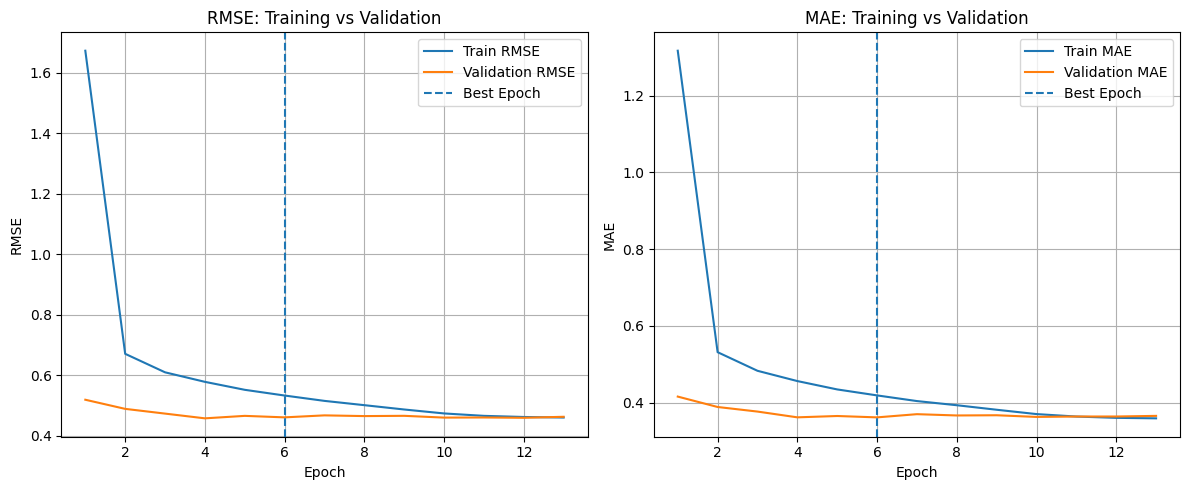

In [231]:
epochs = range(1, len(train_mae_list) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- MAE plot ---
ax[1].plot(epochs, train_mae_list, label="Train MAE")
ax[1].plot(epochs, val_mae_list, label="Validation MAE")
ax[1].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[1].set_title("MAE: Training vs Validation")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MAE")
ax[1].legend()
ax[1].grid()

# --- RMSE plot ---
ax[0].plot(epochs, train_rmse_list, label="Train RMSE")
ax[0].plot(epochs, val_rmse_list, label="Validation RMSE")
ax[0].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[0].set_title("RMSE: Training vs Validation")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("RMSE")
ax[0].legend()
ax[0].grid()

plt.tight_layout()
plt.savefig(model_figs, dpi=300, bbox_inches="tight")
plt.show()

### Evaluation on test set

In [232]:
def collect_predictions(model, df, loader):
    model.eval()

    results = []
    total_time = 0
    total_samples = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating")

        for motion, heart_rate, labels, sample_weights, idx in pbar:
            motion = motion.to(device)
            heart_rate = heart_rate.to(device)

            start = time.time()
            preds = model(motion, heart_rate)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            end = time.time()

            batch_time = end - start
            total_time += batch_time
            total_samples += motion.size(0)

            preds = preds.cpu().numpy()
            labels = labels.cpu().numpy()

            for pred, true, row_idx in zip(preds, labels, idx):
                row = df.iloc[int(row_idx)]
                results.append({
                    "pred": float(pred),
                    "true": float(true),
                    "attention_bin": row["attention_bin"],
                    "gender": row["gender"],
                    "age": row["age"]
                })

    results_df = pd.DataFrame(results)
    metrics = regression_metrics(results_df["true"], results_df["pred"])
    latency_per_batch = total_time / len(loader)
    latency_per_sample = total_time / total_samples

    return results_df, metrics["mae"], metrics["rmse"], latency_per_batch, latency_per_sample

### Fairness Metrics

In [233]:
def compute_group_mae(df, group_col):
    group_mae = df.groupby(group_col).apply(
        lambda x: np.mean(np.abs(x["true"] - x["pred"]))
    )
    worst_group = group_mae.max()
    best_group = group_mae.min()
    gap = worst_group - best_group
    return group_mae, worst_group, gap


def compute_fairness_metrics(results_df):
    metrics = {}

    gender_mae, gender_worst, gender_gap = compute_group_mae(results_df, "gender")
    metrics["gender"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in gender_mae.items()},
        "worst_group_mae": round(float(gender_worst), 5),
        "gap": round(float(gender_gap), 5)
    }

    results_df = results_df.copy()
    results_df["age_group"] = pd.cut(results_df["age"], bins=[13, 17, 20, 22, 26, 44])
    age_mae, age_worst, age_gap = compute_group_mae(results_df, "age_group")
    metrics["age"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in age_mae.items()},
        "worst_group_mae": round(float(age_worst), 5),
        "gap": round(float(age_gap), 5)
    }

    return metrics


def compute_attention_bin_metrics(results_df):
    bin_mae = results_df.groupby("attention_bin").apply(
        lambda x: np.mean(np.abs(x["true"] - x["pred"]))
    )
    bin_count = results_df["attention_bin"].value_counts().sort_index()
    return pd.DataFrame({
        "count": bin_count,
        "mae": bin_mae
    }).sort_index()


def compute_prediction_metrics(results_df, tolerance=0.15, binary_threshold=3.0):
    y_true = results_df["true"].to_numpy(dtype=float)
    y_pred = results_df["pred"].to_numpy(dtype=float)

    binary_true = (y_true >= binary_threshold).astype(int)
    binary_pred = (y_pred >= binary_threshold).astype(int)

    try:
        binary_auc = roc_auc_score(binary_true, y_pred)
    except ValueError:
        binary_auc = np.nan

    return {
        "n_samples": int(len(results_df)),
        "mae": round(float(np.mean(np.abs(y_pred - y_true))), 4),
        "rmse": round(float(np.sqrt(np.mean((y_pred - y_true) ** 2))), 4),
        "r2": round(float(r2_score(y_true, y_pred)), 4),
        "tolerant_accuracy": round(float(np.mean(np.abs(y_pred - y_true) <= tolerance)), 4),
        "tolerance": tolerance,
        "one_off_accuracy": round(float(np.mean(np.abs(np.rint(y_pred) - np.rint(y_true)) <= 1)), 4),
        "binary_threshold": binary_threshold,
        "binary_accuracy": round(float(accuracy_score(binary_true, binary_pred)), 4),
        "binary_f1": round(float(f1_score(binary_true, binary_pred, zero_division=0)), 4),
        "binary_roc_auc": None if np.isnan(binary_auc) else round(float(binary_auc), 4),
        "binary_confusion_matrix": confusion_matrix(binary_true, binary_pred).tolist(),
        "true_mean": round(float(np.mean(y_true)), 4),
        "pred_mean": round(float(np.mean(y_pred)), 4),
    }


def append_experiment_results(results, csv_path, jsonl_path):
    flat_row = {
        "run_id": results["run_id"],
        "experiment_name": results["experiment_name"],
        "created_at": results["created_at"],
        "mae": results["mae"],
        "rmse": results["rmse"],
        "tolerant_accuracy": results["tolerant_accuracy"],
        "binary_accuracy": results["binary_accuracy"],
        "binary_f1": results["binary_f1"],
        "binary_roc_auc": results["binary_roc_auc"],
        "one_off_accuracy": results["one_off_accuracy"],
        "r2": results["r2"],
        "gender_worst_group_mae": results["fairness"]["gender"]["worst_group_mae"],
        "gender_gap": results["fairness"]["gender"]["gap"],
        "gender_mae_per_group": json.dumps(results["fairness"]["gender"]["mae_per_group"], sort_keys=True),
        "age_worst_group_mae": results["fairness"]["age"]["worst_group_mae"],
        "age_gap": results["fairness"]["age"]["gap"],
        "age_mae_per_group": json.dumps(results["fairness"]["age"]["mae_per_group"], sort_keys=True),
        "loss_type": results["loss_type"],
        "sequence_length": results["sequence_length"],
        "use_weighted_loss": results["use_weighted_loss"],
        "use_weighted_sampler": results["use_weighted_sampler"],
        "weight_alpha": results["weight_alpha"],
        "best_epoch": results["best_epoch"],
        "training_time_sec": results["training_time_sec"],
        "latency_per_sample_ms": results["latency_per_sample_ms"],
    }

    new_row = pd.DataFrame([flat_row])
    if os.path.exists(csv_path):
        experiment_log = pd.read_csv(csv_path)
        experiment_log = pd.concat([experiment_log, new_row], ignore_index=True, sort=False)
        experiment_log.to_csv(csv_path, index=False)
    else:
        new_row.to_csv(csv_path, index=False)

    with open(jsonl_path, "a") as f:
        f.write(json.dumps(results) + "\n")


def baseline_mae(train_df, eval_df):
    mean_pred = train_df["target"].mean()
    median_pred = train_df["target"].median()
    return {
        "mean_baseline_mae": float((eval_df["target"] - mean_pred).abs().mean()),
        "median_baseline_mae": float((eval_df["target"] - median_pred).abs().mean()),
        "train_mean": float(mean_pred),
        "train_median": float(median_pred)
    }


In [234]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TemporalSplitHeartRateGRU(
    motion_input_dim=MOTION_INPUT_DIM,
    hr_input_dim=HR_INPUT_DIM,
    motion_hidden_dim=64,
    hr_hidden_dim=16,
    dropout=0.3
).to(device)

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

/scratch-local/cfragkiadakis.23088135/ipykernel_3113877/3261891159.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_loca

TemporalSplitHeartRateGRU(
  (motion_gru): GRU(9, 64, batch_first=True)
  (hr_gru): GRU(2, 16, batch_first=True)
  (regressor): Sequential(
    (0): Linear(in_features=80, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [235]:
results_df, best_mae, best_rmse, best_latency_batch, best_latency_sample = collect_predictions(model, test_df, test_loader)
fairness_metrics = compute_fairness_metrics(results_df)
attention_bin_metrics = compute_attention_bin_metrics(results_df)
evaluation_metrics = compute_prediction_metrics(results_df)

created_at = time.strftime("%Y-%m-%d %H:%M:%S")
run_id = time.strftime("%Y%m%d_%H%M%S")
results_dir = os.path.dirname(model_results)
os.makedirs(results_dir, exist_ok=True)

results = {
    "run_id": run_id,
    "created_at": created_at,
    "experiment_name": name,
    "model_path": model_path,
    "results_path": model_results,
    **evaluation_metrics,
    "loss_type": LOSS_TYPE,
    "sequence_length": SEQUENCE_LENGTH,
    "max_missing_visual_frames": MAX_MISSING_VISUAL_FRAMES,
    "attention_bins": ATTENTION_BINS,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "motion_input_dim": MOTION_INPUT_DIM,
    "hr_input_dim": HR_INPUT_DIM,
    "sensor_cols": sensor_cols,
    "motion_cols": motion_cols,
    "hr_cols": hr_cols,
    "use_weighted_loss": USE_WEIGHTED_LOSS,
    "use_weighted_sampler": USE_WEIGHTED_SAMPLER,
    "weight_alpha": WEIGHT_ALPHA,
    "early_stopping_metric": globals().get("EARLY_STOPPING_METRIC"),
    "best_epoch": None if globals().get("best_epoch") is None else int(best_epoch) + 1,
    "num_epochs_run": len(globals().get("train_losses", [])),
    "learning_rate": globals().get("learning_rate"),
    "training_time_sec": None if "training_start" not in globals() or "training_end" not in globals() else round(float(training_end - training_start), 2),
    "latency_per_batch": round(float(best_latency_batch),4),
    "latency_per_sample_ms": round(float(best_latency_sample * 1000),4),
    "train_final_mae": None if not globals().get("train_mae_list") else round(float(train_mae_list[-1]), 4),
    "train_final_rmse": None if not globals().get("train_rmse_list") else round(float(train_rmse_list[-1]), 4),
    "val_final_mae": None if not globals().get("val_mae_list") else round(float(val_mae_list[-1]), 4),
    "val_final_rmse": None if not globals().get("val_rmse_list") else round(float(val_rmse_list[-1]), 4),
    "fairness": fairness_metrics,
    "attention_bin_mae": {
        str(idx): {
            "count": int(row["count"]),
            "mae": round(float(row["mae"]), 5)
        }
        for idx, row in attention_bin_metrics.iterrows()
    }
}

with open(model_results, "w") as f:
    json.dump(results, f, indent=4)

experiment_log_csv = os.path.join(results_dir, "experiment_log.csv")
experiment_log_jsonl = os.path.join(results_dir, "experiment_log.jsonl")

append_experiment_results(results, experiment_log_csv, experiment_log_jsonl)

display(pd.Series(evaluation_metrics))
attention_bin_metrics

Evaluating: 100%|██████████| 135/135 [00:01<00:00, 68.12it/s]
/scratch-local/cfragkiadakis.23088135/ipykernel_3113877/3712075634.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_mae = df.groupby(group_col).apply(
/scratch-local/cfragkiadakis.23088135/ipykernel_3113877/3712075634.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_mae = df.groupby(group_col).apply(
/scratch-local/cfragkiadakis.23088135/ipykernel_3113877/3712075634.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the

n_samples                                         17271
mae                                              0.3345
rmse                                             0.4381
r2                                              -0.0847
tolerant_accuracy                                0.3163
tolerance                                          0.15
one_off_accuracy                                 0.9965
binary_threshold                                    3.0
binary_accuracy                                  0.5494
binary_f1                                        0.5712
binary_roc_auc                                   0.6198
binary_confusion_matrix    [[4305, 2135], [5648, 5183]]
true_mean                                        3.0294
pred_mean                                         2.991
dtype: object

,count,mae
attention_bin,,
"(1.999, 2.5]",2383,0.511768
"(2.5, 3.0]",9171,0.195636
"(3.0, 3.5]",4215,0.380259
"(3.5, 4.75]",1502,0.772261


In [236]:
print('MAE:', results['mae'])

MAE: 0.3345


In [237]:
print("MAE per gender:\n", results['fairness']['gender']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['gender']['worst_group_mae']}")
print(f"Gap: {results['fairness']['gender']['gap']}")

MAE per gender:
 {'female': 0.32086, 'male': 0.37032}

Worst-group MAE: 0.37032
Gap: 0.04946


In [238]:
print("MAE per age:\n", results['fairness']['age']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['age']['worst_group_mae']}")
print(f"Gap: {results['fairness']['age']['gap']}")

MAE per age:
 {'(13, 17]': 0.28049, '(17, 20]': 0.33759, '(20, 22]': 0.33337, '(22, 26]': 0.38185, '(26, 44]': 0.30666}

Worst-group MAE: 0.38185
Gap: 0.10137


In [239]:
print("Validation baselines:", baseline_mae(train_df, val_df))
print("Test baselines:", baseline_mae(train_df, test_df))

Validation baselines: {'mean_baseline_mae': 0.35977840080492585, 'median_baseline_mae': 0.34862828438948995, 'train_mean': 2.930129536844678, 'train_median': 3.0}
Test baselines: {'mean_baseline_mae': 0.32469464441636375, 'median_baseline_mae': 0.3069306930693069, 'train_mean': 2.930129536844678, 'train_median': 3.0}


In [240]:
preds = results_df['pred']
print(preds.min())
print(preds.max())
print(preds.mean())
print(preds.std())

1.786842703819275
4.23862361907959
2.9909757522321603
0.25867754377964336


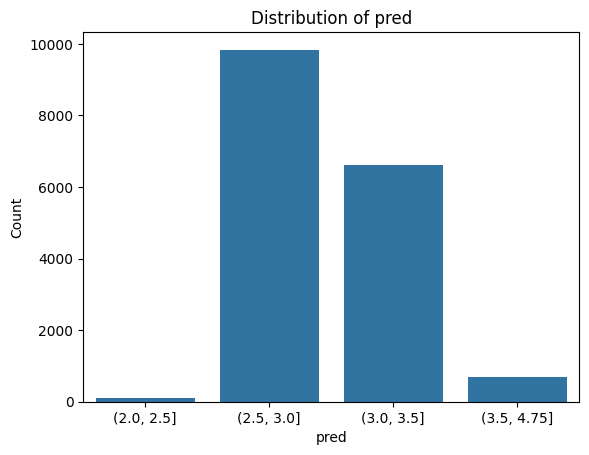

In [241]:
import seaborn as sns

results_df["pred_group"] = pd.cut(results_df["pred"], bins=ATTENTION_BINS)
plt.figure()
sns.countplot(x='pred_group', data=results_df)
plt.title("Distribution of pred")
plt.xlabel("pred")
plt.ylabel("Count")
plt.show()

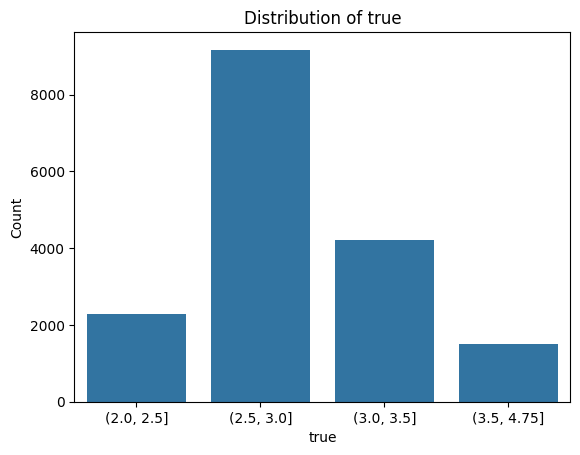

In [242]:
results_df["true_group"] = pd.cut(results_df["true"], bins=ATTENTION_BINS)
plt.figure()
sns.countplot(x='true_group', data=results_df)
plt.title("Distribution of true")
plt.xlabel("true")
plt.ylabel("Count")
plt.show()

In [243]:
print(r2_score(results_df['true'], results_df['pred']))

-0.08474597198268574


In [2]:
experiment_log_csv = os.path.join("results/Sensors Temporal", "experiment_log.csv")

if os.path.exists(experiment_log_csv):
    experiment_log = pd.read_csv(experiment_log_csv)
    display(experiment_log.sort_values("created_at", ascending=False).reset_index(drop=True))
else:
    print(f"No experiment log found yet: {experiment_log_csv}")

,run_id,experiment_name,created_at,mae,rmse,tolerant_accuracy,binary_accuracy,binary_f1,binary_roc_auc,one_off_accuracy,r2,gender_worst_group_mae,gender_gap,gender_mae_per_group,age_worst_group_mae,age_gap,age_mae_per_group,loss_type,sequence_length,use_weighted_loss,use_weighted_sampler,weighting_alpha,best_epoch,training_time_sec,latency_per_sample_ms,weight_alpha
0,20260524_145956,1.10_split_hr_smooth_l1_weighted_loss_a1,2026-05-24 14:59:56,0.3345,0.4381,0.3163,0.5494,0.5712,0.6198,0.9965,-0.0847,0.37032,0.04946,"{""female"": 0.32086, ""male"": 0.37032}",0.38185,0.10137,"{""(13, 17]"": 0.28049, ""(17, 20]"": 0.33759, ""(20, 22]"": 0.33337, ""(22, 26]"": 0.38185, ""(26, 44]"": 0.30666}",smooth_l1,10,True,False,NaN,6,98.43,0.0067,1.0
1,20260524_144419,1.10_split_hr_smooth_l1_weighted_loss_a0.5,2026-05-24 14:44:19,0.3187,0.4239,0.3615,0.4986,0.4155,0.6250,0.9979,-0.0158,0.34902,0.04178,"{""female"": 0.30725, ""male"": 0.34902}",0.35354,0.13350,"{""(13, 17]"": 0.30129, ""(17, 20]"": 0.22004, ""(20, 22]"": 0.34686, ""(22, 26]"": 0.35354, ""(26, 44]"": 0.28092}",smooth_l1,10,True,False,NaN,13,157.28,0.0077,0.5
2,20260524_143759,1.10_split_hr_mse_weighted_loss_a0.5,2026-05-24 14:37:59,0.3173,0.4207,0.3824,0.5267,0.5042,0.6143,0.9969,-0.0002,0.34961,0.04459,"{""female"": 0.30502, ""male"": 0.34961}",0.35663,0.11737,"{""(13, 17]"": 0.27494, ""(17, 20]"": 0.23926, ""(20, 22]"": 0.34185, ""(22, 26]"": 0.35663, ""(26, 44]"": 0.28672}",mse,10,True,False,NaN,11,136.22,0.0070,0.5
3,20260524_143132,1.10_split_hr_mse_weighted_loss_a0.5,2026-05-24 14:31:32,0.3255,0.4335,0.3323,0.5147,0.4778,0.6097,0.9975,-0.0656,0.34722,0.02992,"{""female"": 0.3173, ""male"": 0.34722}",0.35669,0.07568,"{""(13, 17]"": 0.28101, ""(17, 20]"": 0.29206, ""(20, 22]"": 0.34396, ""(22, 26]"": 0.35669, ""(26, 44]"": 0.29228}",mse,10,True,False,0.50,16,132.53,0.0084,NaN
4,20260524_141039,1.10_split_hr_mse_weighted_loss_a0.75,2026-05-24 14:10:39,0.3444,0.4496,0.3087,0.5277,0.4893,0.6343,0.9923,-0.1462,0.35459,0.01398,"{""female"": 0.3406, ""male"": 0.35459}",0.37091,0.13362,"{""(13, 17]"": 0.35694, ""(17, 20]"": 0.23729, ""(20, 22]"": 0.37091, ""(22, 26]"": 0.36474, ""(26, 44]"": 0.31409}",mse,10,True,False,0.75,7,77.04,0.0070,NaN
5,20260524_140558,1.10_split_hr_mse_weighted_loss_a0.75,2026-05-24 14:05:58,0.3306,0.4366,0.3203,0.5497,0.5203,0.6912,0.9937,-0.0811,0.33565,0.01853,"{""female"": 0.33565, ""male"": 0.31712}",0.37358,0.15464,"{""(13, 17]"": 0.32574, ""(17, 20]"": 0.21895, ""(20, 22]"": 0.37358, ""(22, 26]"": 0.32746, ""(26, 44]"": 0.31264}",mse,10,True,False,0.75,4,60.50,0.0070,NaN
6,20260524_135910,1.10_split_hr_mse_weighted_loss_a0.5,2026-05-24 13:59:10,0.3410,0.4420,0.2777,0.5234,0.5032,0.6126,0.9949,-0.1076,0.40419,0.08716,"{""female"": 0.31703, ""male"": 0.40419}",0.42448,0.20564,"{""(13, 17]"": 0.33379, ""(17, 20]"": 0.21884, ""(20, 22]"": 0.34506, ""(22, 26]"": 0.42448, ""(26, 44]"": 0.29454}",mse,10,True,False,0.50,4,61.56,0.0080,NaN
